In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

%pip install ipywidgets jupyter

model_rf = joblib.load('../disk_model.pkl')
X_test = pd.read_csv('../X_test_shap.csv')

#explainer - shap razlaga
#za drevesen modele random forest, XGboost, uporabimo TreeExplainer
explainer = shap.TreeExplainer(model_rf)

shap_values = explainer.shap_values(X_test)

#lahko vrnemo matriko ali 3D matriko ali lista
if isinstance(shap_values, list):
    shap_values_failures = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_failure = shap_values[:, :, 1]
else:
    shap_values_failure = shap_values

shap.initjs()


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


**VIZUALIZACIJA ODLOČITVE MODELA (GRAFI)**


--- PRIKAZ GLOBALNE POMEMBNOSTI ZNAČILNIC ---


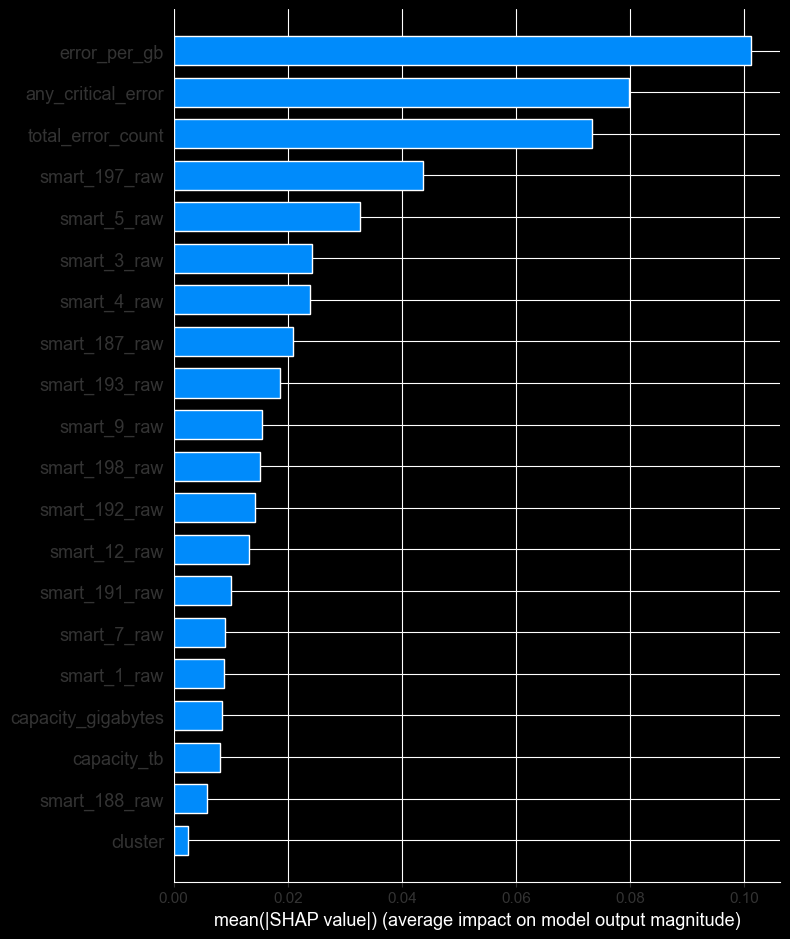


--- ODLOČANJE MODELA ZA VSE DISKE ---


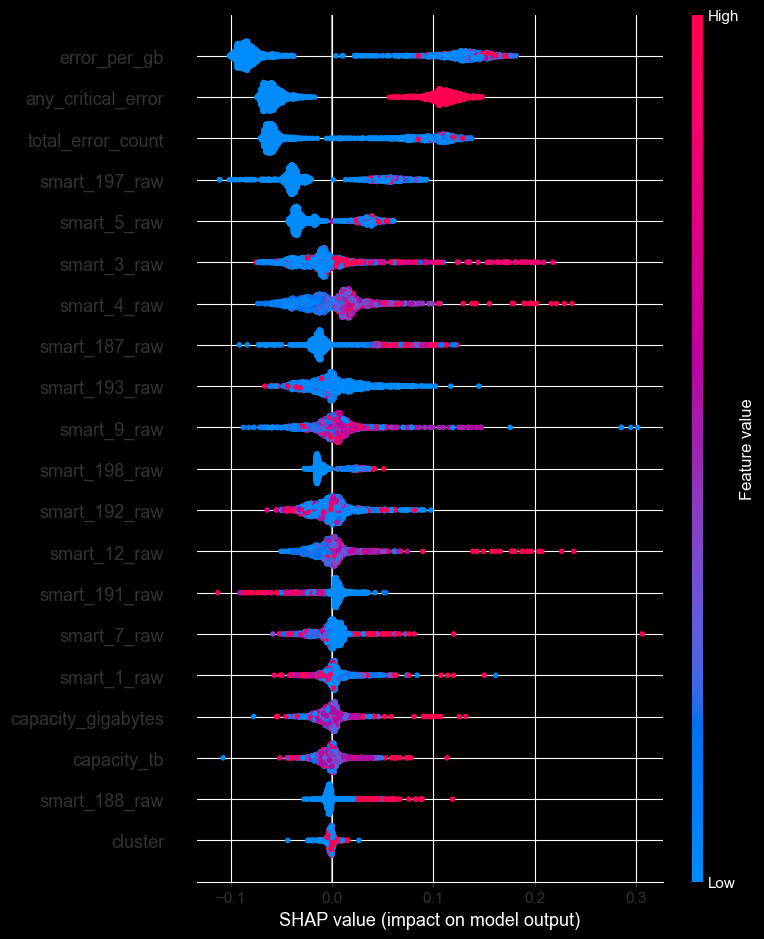


--- PRIKAZ ODLOČITVE ZA POSAMEZEN DISK ---

--- NAJBOLJ KRITIČEN DISK: ---


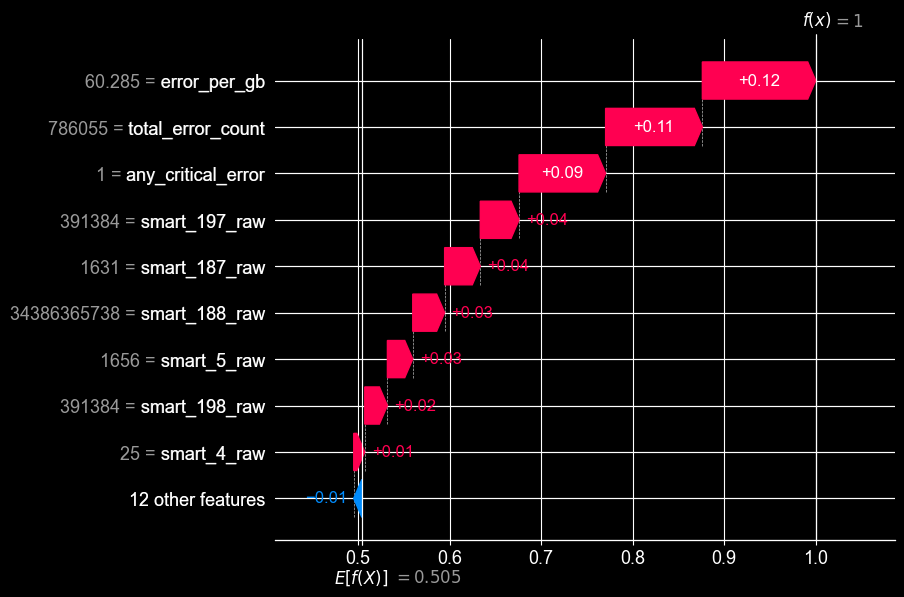


--- NAJBOLJ OPTIMALEN DISK: ---


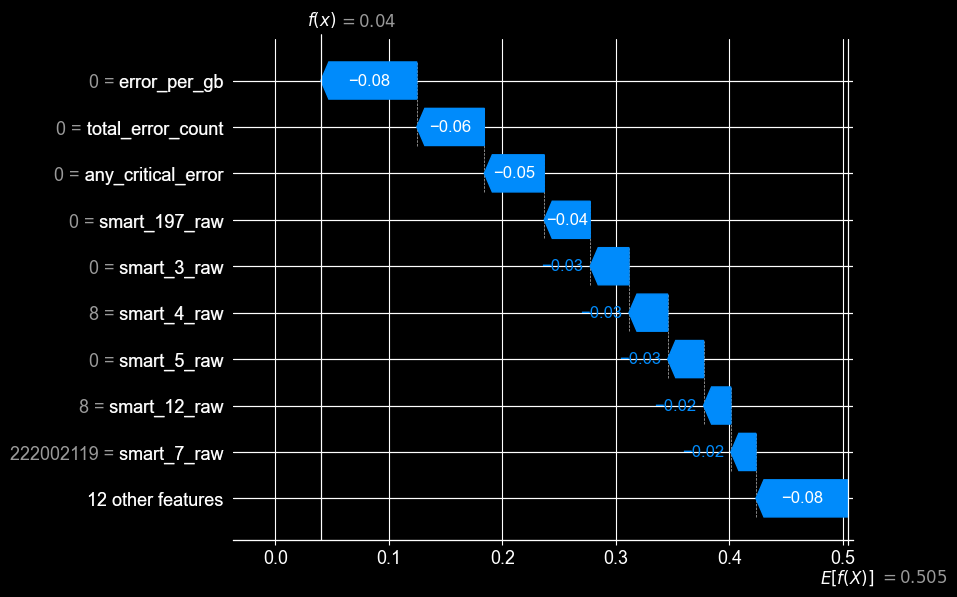


--- NEKJE UMES: ---


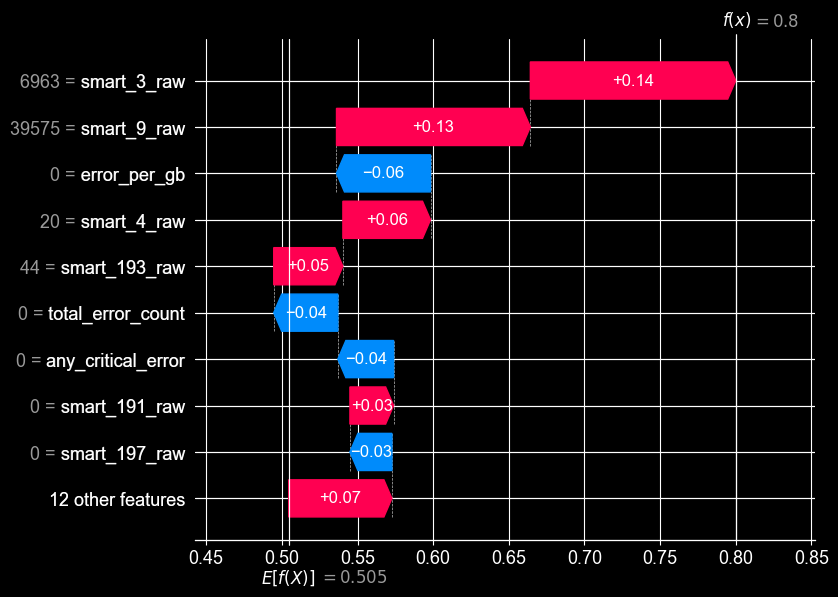


--- PRIKAZ VPLIVA STAROSTI DISKA (SMART 9) ---


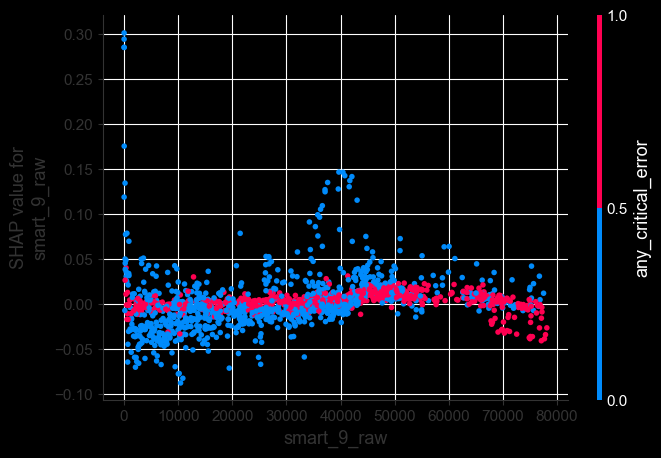

In [8]:

#Klasičen bar plot (povprečni absolutni vpliv)
print("\n--- PRIKAZ GLOBALNE POMEMBNOSTI ZNAČILNIC ---")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_failure, X_test, plot_type="bar")

print("\n--- ODLOČANJE MODELA ZA VSE DISKE ---")
#Beeswarm graf (gostota in smer vpliva za vsak disk posebej)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_failure, X_test)


print("\n--- PRIKAZ ODLOČITVE ZA POSAMEZEN DISK ---")

def odlocitvePosaznegaDiska(izbrani_idx):

    # Priprava Explanation objekta, ki ga zahteva funkcija waterfall
    domena_razlage = shap.Explanation(
        values=shap_values_failure[izbrani_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test.iloc[izbrani_idx],
        feature_names=X_test.columns
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(domena_razlage)

print("\n--- NAJBOLJ KRITIČEN DISK: ---")
odlocitvePosaznegaDiska(879)
print("\n--- NAJBOLJ OPTIMALEN DISK: ---")
odlocitvePosaznegaDiska(1)
print("\n--- NEKJE UMES: ---")
odlocitvePosaznegaDiska(1588)

print("\n--- PRIKAZ VPLIVA STAROSTI DISKA (SMART 9) ---")

#pri kolikšnem številu ur začne starost drastično dvigovati tveganje
shap.dependence_plot("smart_9_raw", shap_values_failure, X_test)

#shap value for raw 9 je "kazen" glede na koliko doprinese starost k analizi na koncu... pac cuden graf je